plot charts

In [1]:
TOPK_LIST = [1, 5, 10, 20]

# ---- Similarity metrics (same as previous experiments) ----
SIM_METRICS = ["cosine", "dot", "neg_l2"]  # higher is better for all

# ---- Threshold definition (class-adaptive) ----
# T_L = mu_L - alpha * sigma_L  (alpha=1 => your current design)
THRESH_ALPHA = 1.0

# ---- Output Excel ----
OUT_XLSX = "filtered_static_threshold_results.xlsx"

C:\Users\Alire\AppData\Local\Temp\ipykernel_12084\3741118410.py:102: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 1, 0.95], pad=0.25)


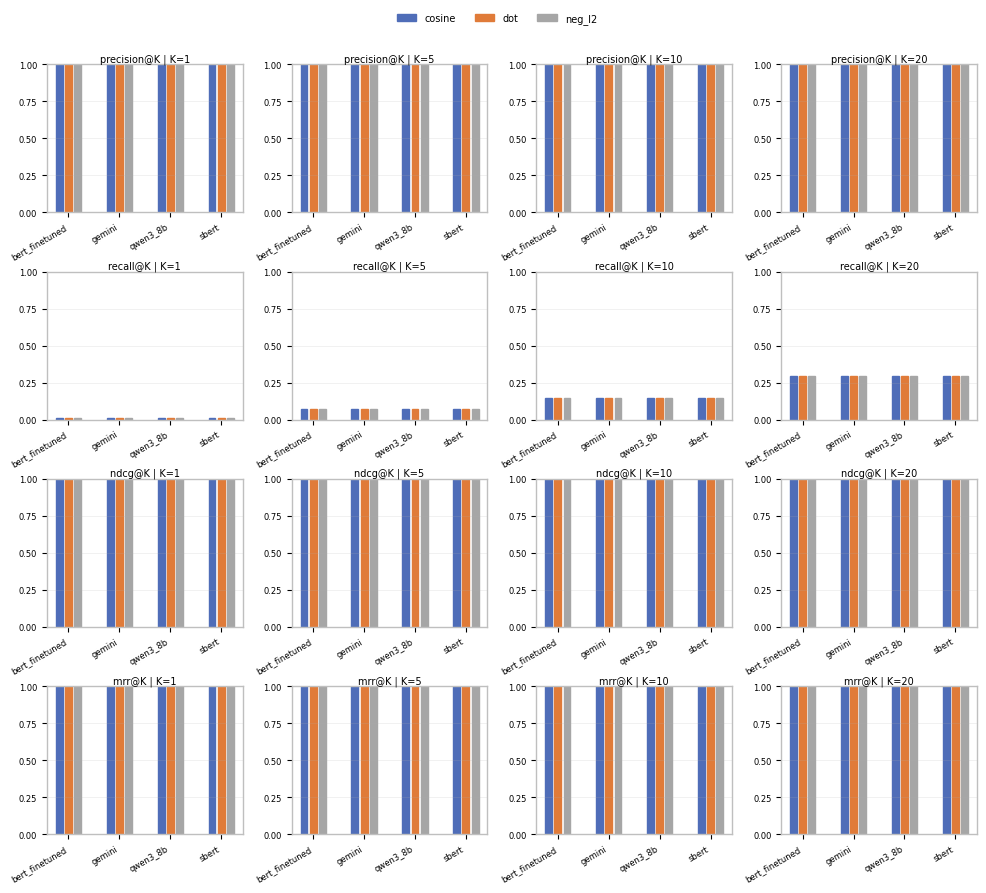

In [6]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RESULT_XLSX = OUT_XLSX  # "filtered_static_threshold_results.xlsx"
df = pd.read_excel(RESULT_XLSX, sheet_name="Summary", engine="openpyxl")

# فقط روش ما
df = df[df["method"].astype(str).str.contains("filtered_static_threshold", case=False, na=False)].copy()
df["K"] = df["K"].astype(int)

K_LIST = [1, 5, 10, 20]
df = df[df["K"].isin(K_LIST)]

# فقط metricهای سه‌گانه قبلی (برای مقایسه مستقیم)
df_main = df[df["metric"].isin(["cosine", "dot", "neg_l2"])].copy()

score_cols = ["precision@K", "recall@K", "ndcg@K", "mrr@K"]
colors = ["#4F6DB8", "#E07B39", "#A6A6A6"]  # blue, orange, gray
metric_order = ["cosine", "dot", "neg_l2"]

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#BFBFBF",
    "axes.linewidth": 1.0,
    "font.size": 7,
    "axes.titlesize": 7,
    "axes.labelsize": 7,
    "xtick.labelsize": 6,
    "ytick.labelsize": 6,
    "legend.fontsize": 7
})

fig, axes = plt.subplots(
    4, 4,
    figsize=(12, 10),
    gridspec_kw={"hspace": 0.40, "wspace": 0.25}
)

# fig.suptitle(
#     f"Filtered Static Search (Label Filter) — Ranking Metrics",
#     fontsize=12, y=0.965
# )

legend_handles, legend_labels = None, None

ymin, ymax = 0.0, 1.0
yticks = np.linspace(0, 1, 5)

for row, score_col in enumerate(score_cols):
    for col, K_FIXED in enumerate(K_LIST):
        ax = axes[row, col]
        sub = df_main[df_main["K"] == K_FIXED]

        pivot = sub.pivot_table(
            index="embedding",
            columns="metric",
            values=score_col,
            aggfunc="mean"
        ).sort_index()

        embeddings = pivot.index.tolist()
        sim_metrics = [m for m in metric_order if m in pivot.columns.tolist()]

        x = np.arange(len(embeddings))
        bar_w = 0.18

        for j, met in enumerate(sim_metrics):
            ax.bar(
                x + (j - (len(sim_metrics) - 1) / 2) * bar_w,
                pivot[met].values,
                width=bar_w * 0.75,
                color=colors[j % len(colors)],
                edgecolor=colors[j % len(colors)],
                label=str(met)
            )

        if legend_handles is None:
            legend_handles, legend_labels = ax.get_legend_handles_labels()

        ax.set_title(f"{score_col} | K={K_FIXED}", pad=2)
        ax.set_xticks(x)
        ax.set_xticklabels(embeddings, rotation=30, ha="right")

        ax.set_ylim(ymin, ymax)
        ax.set_yticks(yticks)

        ax.grid(True, axis="y", linewidth=0.5, alpha=0.25)
        ax.grid(False, axis="x")

if legend_handles and legend_labels:
    fig.legend(
        legend_handles,
        legend_labels,
        loc="upper center",
        ncol=len(legend_labels),
        frameon=False,
        bbox_to_anchor=(0.5, 0.94)
    )

plt.tight_layout(rect=[0, 0, 1, 0.95], pad=0.25)
plt.show()

In [ ]:
FIG_NAME = "Filtered_Static_Search_Label_Filter_Ranking_Metrics.png"

fig.savefig(
    FIG_NAME,
    dpi=600,              
    bbox_inches="tight"
)

print("Figure saved as:", FIG_NAME)

✅ Figure saved as: Filtered_Static_Search_Label_Filter_Ranking_Metrics.png


separate chart for Threshold-Precision@K

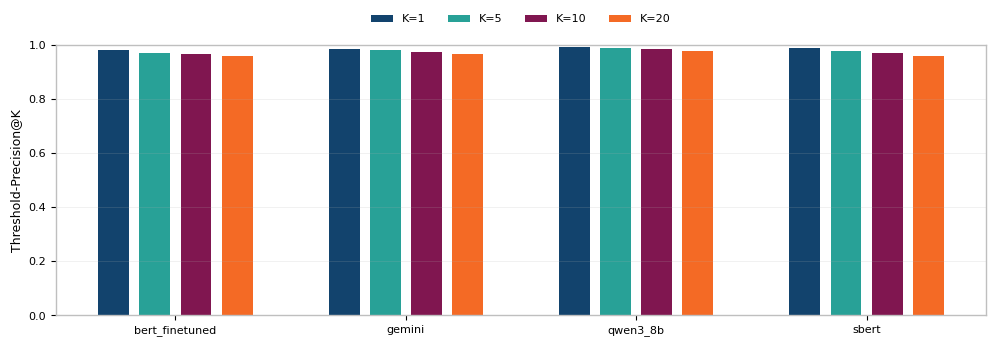

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

RESULT_XLSX = OUT_XLSX
df = pd.read_excel(RESULT_XLSX, sheet_name="Summary", engine="openpyxl")

df = df[df["method"].astype(str).str.contains("filtered_static_threshold", case=False, na=False)].copy()
df["K"] = df["K"].astype(int)

K_LIST = [1, 5, 10, 20]
df = df[df["K"].isin(K_LIST)]

# فقط ردیف‌های threshold
df_thr = df[df["metric"] == "cosine_threshold"].copy()

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.edgecolor": "#BFBFBF",
    "axes.linewidth": 1.0,
    "font.size": 8,
    "axes.titlesize": 9,
    "axes.labelsize": 9,
    "xtick.labelsize": 8,
    "ytick.labelsize": 8,
    "legend.fontsize": 8
})

fig, ax = plt.subplots(figsize=(10, 3.5))

pivot = df_thr.pivot_table(
    index="embedding",
    columns="K",
    values="threshold_precision@K",
    aggfunc="mean"
).sort_index()

embeddings = pivot.index.tolist()
group_spacing = 0.28   
x = np.arange(len(embeddings)) * group_spacing
Ks = K_LIST
bar_w = 0.05

palette = ["#12436D", "#28A197", "#801650", "#F46A25"]

for j, K in enumerate(Ks):
    ax.bar(
        x + (j - (len(Ks) - 1) / 2) * bar_w,
        pivot[K].values,
        width=bar_w * 0.75,
        label=f"K={K}",
        color=palette[j]
    )

ax.set_ylabel("Threshold-Precision@K")
ax.set_xticks(x)
ax.set_xticklabels(embeddings, rotation=0, ha="center")
ax.set_ylim(0.0, 1.0)
ax.set_yticks(np.linspace(0, 1, 6))
ax.grid(True, axis="y", linewidth=0.5, alpha=0.25)
ax.legend(ncol=len(Ks), frameon=False, loc="upper center", bbox_to_anchor=(0.5, 1.15))

plt.tight_layout()
plt.show()

In [ ]:
FIG_NAME = "Filtered_Static_Search_Threshold_Precision_at_K_cosine.png"

fig.savefig(
    FIG_NAME,
    dpi=600,             
    bbox_inches="tight"
)

print("Figure saved as:", FIG_NAME)

✅ Figure saved as: Filtered_Static_Search_Threshold_Precision_at_K_cosine.png


only NDGC and accuracy (cosine similarity)

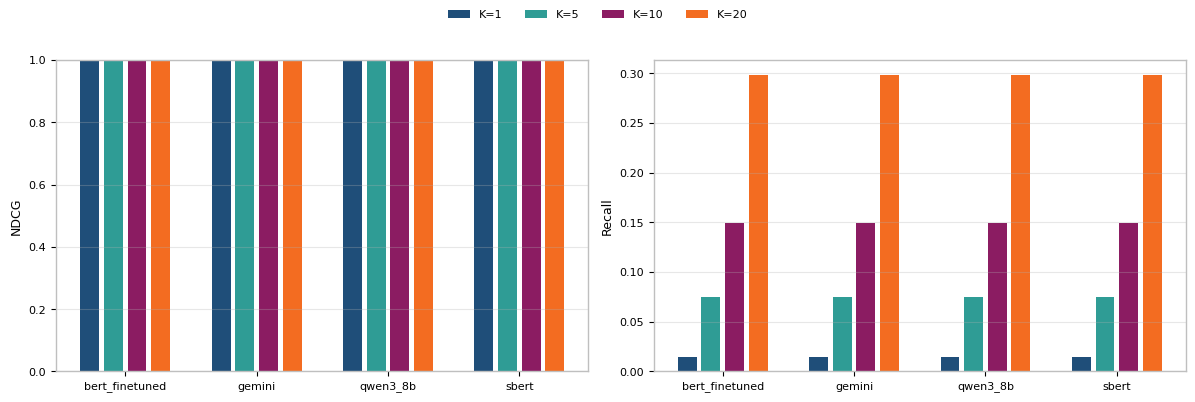

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

XLSX = "filtered_static_threshold_results.xlsx"
SHEET = "Summary"

K_LIST = [1,5,10,20]

df = pd.read_excel(XLSX, sheet_name=SHEET)

df = df[df["metric"].str.lower()=="cosine"]

df["K"] = df["K"].astype(int)
df = df[df["K"].isin(K_LIST)]

pivot_ndcg = df.pivot_table(index="embedding",columns="K",values="ndcg@K")
pivot_recall = df.pivot_table(index="embedding",columns="K",values="recall@K")

embeddings = pivot_ndcg.index.tolist()
x = np.arange(len(embeddings))
bar_w = 0.18

colors = ["#1f4e79","#2f9c95","#8b1c62","#f36c21"]

fig, axes = plt.subplots(1,2,figsize=(12,4))

# -------- NDCG --------
ax = axes[0]

for j,K in enumerate(K_LIST):
    ax.bar(
        x + (j-(len(K_LIST)-1)/2)*bar_w,
        pivot_ndcg[K],
        # width=bar_w,
        width=bar_w * 0.80,
        color=colors[j],
        label=f"K={K}"
    )

# ax.set_title("Filtered Vector Search — NDCG@K (cosine)")
ax.set_ylabel("NDCG")
ax.set_xticks(x)
ax.set_xticklabels(embeddings,rotation=0,ha="center")
ax.set_ylim(0,1)
ax.grid(axis="y",alpha=0.3)

# -------- Recall --------
ax = axes[1]

for j,K in enumerate(K_LIST):
    ax.bar(
        x + (j-(len(K_LIST)-1)/2)*bar_w,
        pivot_recall[K],
        # width=bar_w,
        width=bar_w * 0.80,
        color=colors[j],
        label=f"K={K}"
    )

# ax.set_title("Filtered Vector Search — Recall@K (cosine)")
ax.set_ylabel("Recall")
ax.set_xticks(x)
ax.set_xticklabels(embeddings,rotation=0,ha="center")
ax.grid(axis="y",alpha=0.3)

# legend مشترک
handles, labels = axes[0].get_legend_handles_labels()
fig.legend(handles, labels, loc="upper center", ncol=4, frameon=False)

plt.tight_layout(rect=[0,0,1,0.9])
plt.show()

In [ ]:
FIG_NAME = "Filtered_Vector_Search_NDGC_Accuracy_cosine.png"

fig.savefig(
    FIG_NAME,
    dpi=600,              
    bbox_inches="tight"
)

print("Figure saved as:", FIG_NAME)

✅ Figure saved as: Filtered_Vector_Search_NDGC_Accuracy_cosine.png
